#  6장 건강상태를 알면 당뇨병을 예측할 수 있을까?

## 1 데이터 불러오기

피마 인디언 당뇨병 데이터
https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

1.1 파일 업로드하기

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving diabetes.csv to diabetes.csv


1.2 데이터프레임 생성하기

In [ ]:
import pandas as pd
df = pd.read_csv('/content/diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


##2. 탐색적 데이터 분석 및 전처리하기

2.1 데이터 살펴보기

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


2.2 빈도수 확인하기

(1) 클래스 빈도수 확인하기

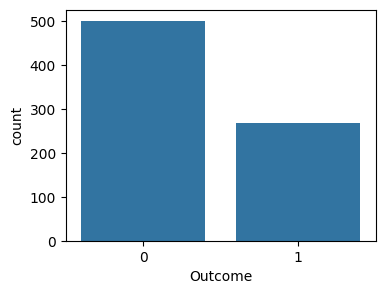

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(4,3))
sns.countplot(x="Outcome", data=df)
plt.show()

2.3 특징 통계값 확인하기

(1) 특징 통계값 확인하기

In [ ]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


(2) 속성별 0의 개수 확인하기

In [ ]:
print("Number of rows with 0 values for each variable")
for col in df.columns:
  missing_rows=df.loc[df[col]==0].shape[0]
  print(col+":", missing_rows)

Number of rows with 0 values for each variable
Pregnancies: 111
Glucose: 5
BloodPressure: 35
SkinThickness: 227
Insulin: 374
BMI: 11
DiabetesPedigreeFunction: 0
Age: 0
Outcome: 500


2.4 이상치 확인하기




(1) 산점도로 이상치 확인하기

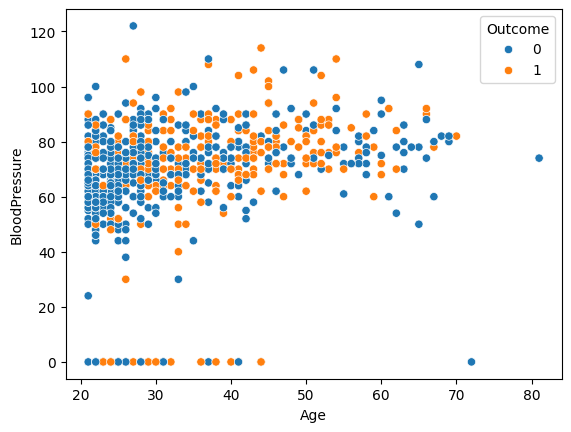

In [ ]:
sns.scatterplot(x='Age', y='BloodPressure', hue='Outcome', data=df)
plt.show()

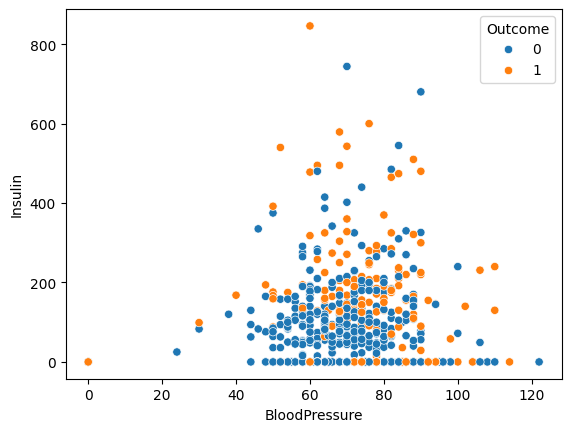

In [ ]:
sns.scatterplot(x='BloodPressure', y='Insulin', hue='Outcome', data=df)
plt.show()

(2) 박스 플롯으로 이상치 확인하기

<Axes: >

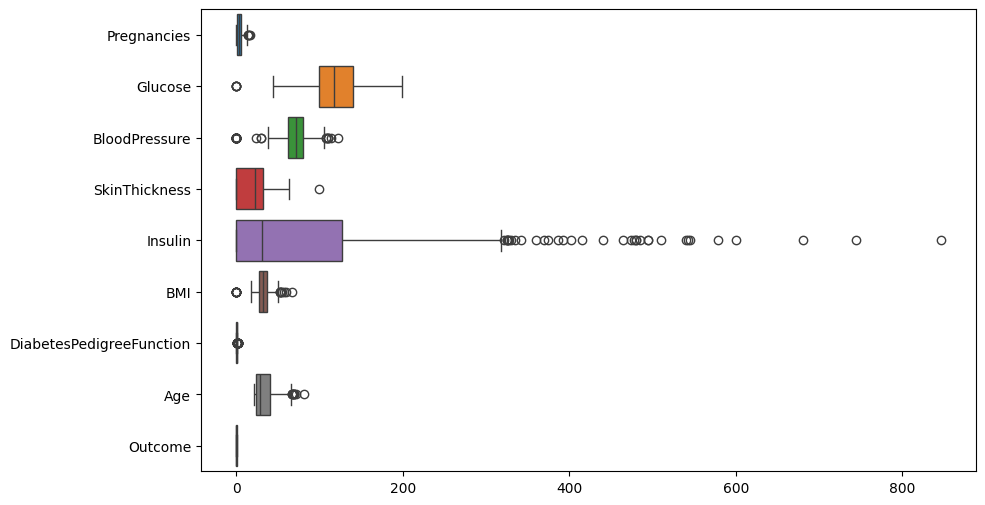

In [ ]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df, orient='h')

2.5 이상치 처리하기

In [ ]:
Preg_range=(df.Pregnancies>=0)&(df.Pregnancies<=13.5)
Gluc_range=(df.Glucose>=36.75)&(df.Glucose<=202.75)
Bloo_range=(df.BloodPressure>=35)&(df.BloodPressure<=107)
Skin_range=(df.SkinThickness>=1)&(df.SkinThickness<=80)
Insu_range=(df.Insulin>=1)&(df.Insulin<=318.75)
BMI_range=(df.BMI>=13.35)&(df.BMI<=50.55)
diab_range=(df.DiabetesPedigreeFunction>=0)&(df.DiabetesPedigreeFunction<=1.22)
Age_range=(df.Age>=21)&(df.Age<=65.5)
df2=df.loc[Preg_range&Gluc_range&Bloo_range&Skin_range&Insu_range&BMI_range&diab_range&Age_range,:]
df2

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,1,89,66,23,94,28.1,0.167,21,0
6,3,78,50,32,88,31.0,0.248,26,1
14,5,166,72,19,175,25.8,0.587,51,1
16,0,118,84,47,230,45.8,0.551,31,1
19,1,115,70,30,96,34.6,0.529,32,1
...,...,...,...,...,...,...,...,...,...
751,1,121,78,39,74,39.0,0.261,28,0
755,1,128,88,39,110,36.5,1.057,37,1
760,2,88,58,26,16,28.4,0.766,22,0
763,10,101,76,48,180,32.9,0.171,63,0


2.6 독립변수와 종속변수 선정하기




In [ ]:
X = df2.drop('Outcome', axis = 1) # Outcome을 제외하고 독립변수 X에 저장
y = df2['Outcome']                # 종속변수 Outcome을 y에 저장

In [ ]:
print("특징 모양: ", X.shape)
print("타깃 모양: ", y.shape)

특징 모양:  (332, 8)
타깃 모양:  (332,)


2.7 데이터 정규화하기

In [ ]:
#  최소-최대 정규화(Min-Max Normalization)
X_scaled= (X-X.min())/(X.max()-X.min())
X_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
3,0.076923,0.232394,0.411765,0.301887,0.260726,0.314286,0.074275,0.000000
6,0.230769,0.154930,0.176471,0.471698,0.240924,0.406349,0.147645,0.119048
14,0.384615,0.774648,0.500000,0.226415,0.528053,0.241270,0.454710,0.714286
16,0.000000,0.436620,0.676471,0.754717,0.709571,0.876190,0.422101,0.238095
19,0.076923,0.415493,0.470588,0.433962,0.267327,0.520635,0.402174,0.261905



2.8 훈련 데이터, 테스트 데이터 분할하기

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.3, stratify=y, random_state=42)

In [ ]:
print("훈련 데이터 : ", X_train.shape, y_train.shape)
print("테스트 데이터 : ", X_test.shape, y_test.shape)

훈련 데이터 :  (232, 8) (232,)
테스트 데이터 :  (100, 8) (100,)


## **3. 모델 생성하기**

3.1 로지스틱 회귀 모델 학습하기

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression( solver='lbfgs', max_iter=1000, random_state=42)     # Logistic Regression 모델 생성
model.fit(X_train,y_train)

LogisticRegression(max_iter=1000, random_state=42)

3.2 회귀계수와 절편 확인하기

In [ ]:
import numpy as np
w=model.coef_          #회귀 계수
b=model.intercept_     #절편
print("w= ", np.round(w,2))
print("b= ", np.round(b,2))  #np.round()를 이용하여 소숫점 2자리까지 출력

w=  [[0.69 2.82 0.46 0.44 1.09 0.96 0.93 1.1 ]]
b=  [-4.4]


3.3 모델 성능 확인하기

In [ ]:
print("훈련 데이터로 학습한 모델 분류 정확도 : ", model.score(X_train, y_train))

훈련 데이터로 학습한 모델 분류 정확도 :  0.7974137931034483


## **4. 모델 평가 및 예측하기**

4.1 모델 성능 평가하기

In [ ]:
print("테스트 데이터를 이용한 모델 성능 평가 : ", model.score(X_test, y_test))

테스트 데이터를 이용한 모델 성능 평가 :  0.81


4.2 테스트 데이터 예측하기

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
# 실제값과 모델 예측값 출력
result = pd.DataFrame()
result['실제값'] = y_test[:5].values
result['예측값'] = y_pred[:5]
result

,실제값,예측값
0,0,0
1,1,0
2,1,1
3,0,0
4,0,0


혼동 행렬 확인하기

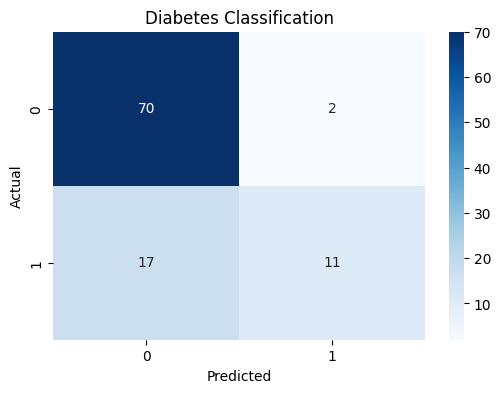

In [ ]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(6, 4))
conf = confusion_matrix(y_test, y_pred)
sns.heatmap(conf, annot=True, cmap="Blues",fmt="g")
plt.title("Diabetes Classification")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

##4.3 모델 개선하기

(1) 훈련 데이터와 테스트 데이터 분할하기

In [ ]:
# 훈련 데이터와 테스트 데이터 분할하기
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)

In [ ]:
print("SMOTE 적용 전 빈도수:", y_train.value_counts())             #    훈련 데이터의 빈도수 확인

SMOTE 적용 전 빈도수: Outcome
0    166
1     66
Name: count, dtype: int64


(2) SMOTE 활용 오버샘플링

In [ ]:
# SMOTE 활용 오버샘플링 (훈련 데이터에만 적용)
from imblearn.over_sampling import SMOTE
oversample = SMOTE(random_state=42)
X_train_smote, y_train_smote = oversample.fit_resample(X_train, y_train)  # SMOTE 활용 훈련 데이터 증강하기

In [ ]:
print("SMOTE 적용 후 빈도수:", y_train_smote.value_counts())    # 오버샘플링 후 빈도수

SMOTE 적용 후 빈도수: Outcome
0    166
1    166
Name: count, dtype: int64


(3) 데이터 정규화하기

In [ ]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test)
y_train = y_train_smote  #  y_train을 SMOTE 결과로 업데이트

(4) 개선된 모델 학습하기

In [ ]:
model2 = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
model2.fit(X_train_scaled, y_train)
print("개선된 모델 분류 정확도 : ", model2.score(X_train_scaled, y_train))

개선된 모델 분류 정확도 :  0.75


(5) 회귀계수 시각화하기

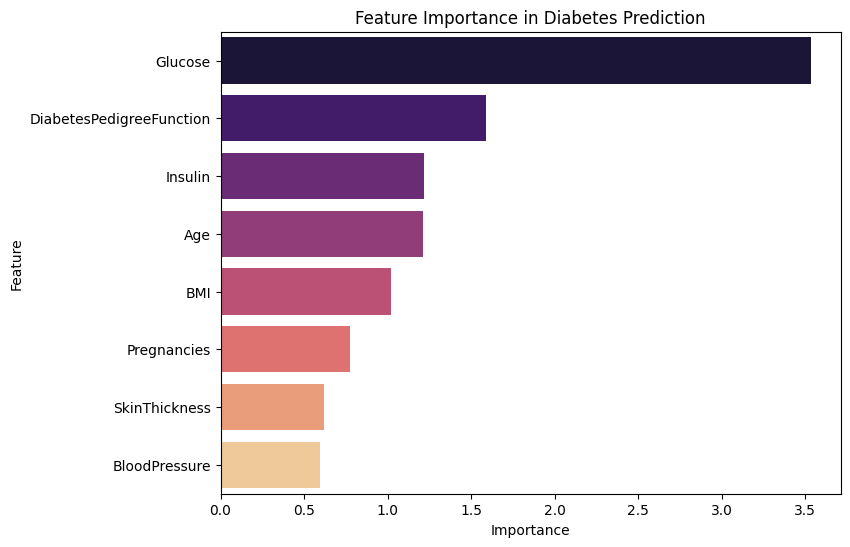

In [ ]:
# 인공지능의 가중치(회귀 계수)를 데이터프레임에 저장
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model2.coef_[0]})
#  중요도가 높은 순서대로 데이터 정렬
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
# 막대그래프(Bar Chart)로 시각화
plt.figure(figsize=(8, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance, palette='magma', hue='Feature', legend=False)
plt.title('Feature Importance in Diabetes Prediction')
plt.show()

(6) 개선된 모델 성능 평가하기

In [ ]:
from sklearn import metrics
y_pred2 = model2.predict(X_test_scaled)
print("개선된 모델 성능 평가:",metrics.accuracy_score(y_test, y_pred2))      # 실제값과 모델2의 예측값 비교

개선된 모델 성능 평가: 0.84


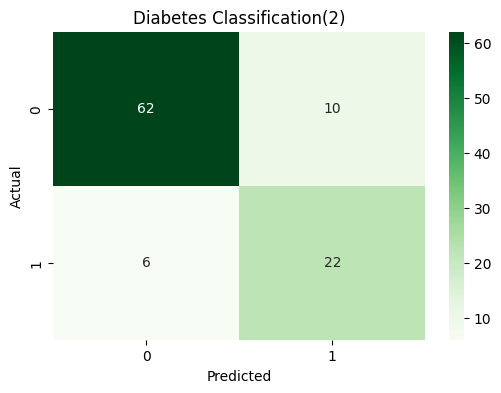

In [ ]:
from sklearn.metrics import confusion_matrix
plt.figure(figsize=(6, 4))

conf = confusion_matrix(y_test,y_pred2)
sns.heatmap(conf, annot=True, cmap="Greens",fmt="g")

plt.title("Diabetes Classification(2)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## 5. 모델 활용하기

5.1 새로운 데이터 불러오기

In [ ]:
# 파일 업로드
from google.colab import files
uploaded = files.upload()

Saving new_diabetes.csv to new_diabetes.csv


In [ ]:
df_new = pd.read_csv('new_diabetes.csv')
df_new.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,10,168,74,30,100,38.0,0.537,34
1,4,129,86,20,270,35.1,0.231,23
2,7,155,54,35,180,30.5,0.588,40
3,2,75,64,25,50,29.7,0.370,33
4,1,99,65,16,55,23.6,0.666,27


5.2 새로운 데이터 정규화하기

In [ ]:
# 5.2 새로운 데이터 스케일링하기 (위에서 만든 scaler를 그대로 사용)
df_new_scaled = scaler.transform(df_new)

In [ ]:
df_new_scaled

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,0.769231,0.788732,0.529412,0.433962,0.280528,0.628571,0.409420,0.309524
1,0.307692,0.514085,0.705882,0.245283,0.841584,0.536508,0.132246,0.047619
2,0.538462,0.697183,0.235294,0.528302,0.544554,0.390476,0.455616,0.452381
3,0.153846,0.133803,0.382353,0.339623,0.115512,0.365079,0.258152,0.285714
4,0.076923,0.302817,0.397059,0.169811,0.132013,0.171429,0.526268,0.142857


5.3 새로운 데이터 예측하기

In [ ]:
# 앞에서 만든 feature_importance 데이터프레임에서 상위 3개 특징 추출
top_3_features = feature_importance.head(3)['Feature'].tolist()

# 개선된 모델(model2)로 예측 수행
new_pred = model2.predict(df_new_scaled)
new_prob = model2.predict_proba(df_new_scaled)

# 결과 테이블 구성
df_new['Prediction'] = new_pred
df_new['Probability(%)'] = (new_prob[:, 1] * 100).round(2)

# 핵심 지표(상위 3개)와 예측 결과를 나란히 출력
print("--- [AI 선정] 3대 핵심 지표 기준 예측 결과 ---")
display(df_new[top_3_features + ['Prediction', 'Probability(%)']])

--- [AI 선정] 3대 핵심 지표 기준 예측 결과 ---


,Glucose,DiabetesPedigreeFunction,Insulin,Prediction,Probability(%)
0,168,0.537,100,1,82.14
1,129,0.231,270,1,50.22
2,155,0.588,180,1,76.79
3,75,0.370,50,0,9.90
4,99,0.666,55,0,15.50
